# Assignment A: Building an Economic Data Brief
## ECO6810: Data Analysis for Economics
**Kush Khurana** | Ashoka University | Spring 2026

---

> *You're a junior analyst at a development economics think tank. Your supervisor asks you to prepare a data brief on global economic performance using World Bank data. The brief requires data analysis, visualizations, and critical evaluation of AI-assisted work.*

This assignment covers **Units 1–3** (Python Essentials, pandas Fundamentals, Visualization & EDA).

| Act | Questions | Points |
|-----|-----------|--------|
| I: Comprehend & Predict | Q1–Q3 | 25 |
| II: Analyze & Build | Q4–Q6 | 45 |
| III: Evaluate & Extend | Q7–Q9 | 30 |
| **Total** | | **100** |

**Time:** ~5–7 hours over 7 days • **AI Usage:** Permitted with inline reflection after each Act • **Pre-read:** If you haven't taken development economics, read `preread.md` before starting.

---

In [ ]:
# ⚠️ DO NOT EDIT THIS CELL — it configures grading and submission.
# === SETUP (Run this first) ===
import os, sys, json
IN_COLAB = 'google.colab' in sys.modules or 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'otter-grader'])

import base64, zipfile, io, shutil
if os.path.exists('tests'):
    shutil.rmtree('tests')
_b64 = (
    'UEsDBBQAAAAIAI5pYlz92ty7UQEAAPwGAAALAAAAdGVzdHMvcTEucHndlU1rAjEQhu/7K6bpYS0s'
    'RT0KLogglGKF1puIhCR2g9tkTWaxIv73JtH6tdtTPYg5bSbv7MyTNzCj19lg9D7sjaELY1OKKEJh'
    '0W02EbhFFP0SpANk2SLJLlJoqdC6WKu5j9hSuiQXmYS9X5vDV1Awai8E9cJjgua+rCGE1ArSNAVp'
    'pbJIFRONZWs2lzkKk0AuLT7V5gS82mpkz1Y5yCTnQrlGBjS34g9RrtlC8F9RRbOtpv0D+kAK3S5M'
    '4hfFJY0TiPuZVDSe3i/4udufRpdFAhbNfXsdOL3Vcc86o6/O6nNvBHVeKhZIP3K9uj7pzbj6CP1M'
    'sAVgRvHALS2Ib8owX+/5oYFGssW6A+3npj9+G40hhXb9cz+9wgd3hUPXh6EoburBnEWm5z8hlmkT'
    'kqsFiBVYFn4IXXRHUFDD9UrVnq2LMLi4Zn6iHf3Y9TGNttEPUEsDBBQAAAAIAC5rYlx1THxz9wEA'
    'AJgMAAALAAAAdGVzdHMvcTIucHntl99r2zAQx9/9Vwi92AHPOGYZYyyB/lhexihsfSvGKJaSiiqS'
    'Jsl0peR/30mx0y6xV7Yw2FiMkezzfU93pw82vvpYza8+fzq7RlN0bRoWRY5ZBzePEYIDS7Jm+B3C'
    'Xwucbi1aceks2N62Bttw0IDhJtz743F3FTxqYvcc+h2fBIr6VQ3GuNdhNpshvtbKOKSJpMQiODUd'
    '9K18URVdQl2aZpfEkbmBwpL+5bMsC3O8orpaGXXvbmNI/nWWp2icTVL0JsvL9OdSrXQjiONKVmsu'
    'BMzWxyhyiDHxcSYvhqhVI5158LL4LE5RfO6Hi7gclG1Gwx0wzDbCb+ySf6uWXDhmkq4twzLBZNJK'
    'R2g6RUWvZwCn7wHsX3+R+JZTyiTs8ZwIywachKrvGO2cDnw2h7ITT8Mh/gaeLLSY0Q6pm11OZeaU'
    '4NYlo4BZm+BQbsfw5rX/Km7FL/Jm2ApA2W645cS3tJs/NEZp9uzqJXo8u4tn5I1zj28RxkkgGcZj'
    'UCpalrZJE1HBijuiimE5t1xaR2TNOqyK1HfpCzOc2X7df/vCOhHUI18oJRKysDt+2mJL9CrkNELv'
    'EWQ5PrF0Yuk3WOpK8jTlf5KmIz5tP1j2mo9trUwQHy6ALXON9j8Ie9lhx4ih6l72PnvQ4aeCqtp3'
    '9AnLbR5ltIm+A1BLAwQUAAAACACYaWJcQVCqMJUBAACPBgAACwAAAHRlc3RzL3EzLnB53VXdS8Mw'
    'EH/vX3HEh61QZTBEEDdQ0BcRQXyTIbf0ysLSpCZX5xT/d5N2Tufqk3sY5qX38bvcZ3O3149Xt3c3'
    '5/cwgntXU5IweQ7MWwLhCIMliVMQT0ORtZLKKsM+yE5WAl+rYBMEDw0fz9uaahAS/Q9AN/DLwObR'
    'qxNCdALG4zE8DR+nxEwORiMQF93AJqVOF2KVz5ZipvKcTPB+hdrTLyBt5ZzyT9AW5n3b7A+ZKq+M'
    'ZzSS+iHpxWyZgWeXApocNJmVMIUxDAf/twoHcPlSaTTIyhoo6zClJZmGQXCk6RkNA5OcGSVRg7Sh'
    'YBX/eh+aZX++AGWgrd+Rtgty/RQK66BVPPSeSbJ16rWXQa9AH6YtUo4wx6mmSFNRKKlCIJGpQkvQ'
    'R0pbW8WvrViVrf20VpoPlVnTgZykO29YtN2Hfm1ObXhUVIlMGfTD85FBoS1yuvvs92ZcjwdwNoJv'
    'mUf2eDDY/R/6h4ZvSCablwgvrWuMtx0IT1xXcS/8iE4wocvtwnTqllWzS3Ir45L5ql0bxyR5Tz4A'
    'UEsDBBQAAAAIAIdrYlwJBOGmCgIAAEcMAAALAAAAdGVzdHMvcTQucHntl11r2zAUhu/9Kw7aRRrI'
    'QlOnN4UYBiM3YxTWwi5CMKp0nIgqkibJy0LJf5/sucmc2F5HMwhlxhf6OEcfz5HeY99+Sqe3Xz5/'
    'uIcJ3Nsco8ij86HyFEF4iKIrJDdAvo3J4FeL0UJ5F9pG11WLy0VwCi2zsl48T7tSacGoOzBoNtw7'
    'aF5MawkhjQZJkoBYGW09GKo4dRBew1ttUzsKe/LapCp92KRCccGo1/Zira3kA+gtuEkXVq/9sjeA'
    'uN8+qRPKeaoYXoQxB2HO4Ufq6dQGTs1eJdXGTZIK6VHHUnCOKux/SqXDFiOp2SPyZ6Mjm+2x2ytY'
    'n4yfFM4X5IZMy3ylXB8mE5j1mM6Vt5tefaT5f6B/Boqq4FlyjN8ur3dwFy47cuDoGAZaanEDmbBB'
    'q75TmSMkE5D0uXYi7Nft2B+0lgX3We28DkWAMrucF6tp6Xw/mp9eJwrf84jSV20fHayFXwIXWYYW'
    'lYcdZtcRmKvuwEiRYYo/DLJCfTfd0alU5qpdZQ6HO73UnEtM/i5NxiEKTK8MtZhaXAitXNPdeGGC'
    'jMsEeYdWoHvT2fHV2Co9iesKEv9DzTgbejXRECqT1Ad+e9HowD7uwL4b6aWHdfz7YYVwXarcOu5D'
    'Apfnqw/zepU4pm3pfTwDcehzU3zPHyyPeKSW67Vq7NuY8h+Aa1b8HOwjuS1L82gb/QRQSwMEFAAA'
    'AAgAqGliXHofiZE0AgAAkBAAAAsAAAB0ZXN0cy9xNS5wee1YUW/aMBB+51fc3AeC2kUD1JdJIE1i'
    'bFI3ddr6VqHIxEdizbEz2xmgqv+9jmnGKMm2wqqhsrw4Pn/nc77PPju+vIjGl58/vrmCAVzpAlst'
    'i8a6yk0L3EMkzZC8BvLtnJytLLni0hpn657fW0zBnZOzXPt6+dz8ePOImJoHgHrg2kGxMqwmhNQC'
    'hsMh8CxX2kJGbS6UFXwaznhSaGx0iFx7131aCY80JlxJKqJEq7lNg7nSgnWagxkujaUyxsB3c7Yd'
    'Nxz7or4Pz23tp5J7YrcaUs4YSsfCmAqDDSCh4q/IKtAW5nbbbQ/G9yFQoFwxF9IFmg4MB9D9z1Sj'
    'r2fp+tUkTNBGlluBQQdeDKDdfr6k7bSgexXLc6TCplHqi0cu597RLufd6POeG1N0IegURTVHgUpW'
    'A1pugJ4vsSfwJabWoobFS7rgBkyqCsFA4ww1ukkH70afIBAqARNT0TDH9pOonbC8DVz+QqtQqDlq'
    'J4fS0HaD+UP4X9et9D0s2ZYNsgk+Q8BFjnGZO5ZPIVsZokGI5bEIsdNG0K/4dhM/YtxYzaeFdRvv'
    'I/eC/tHuBTsz6J2P8cRyAu8dTSrRNKuSRUq/I1yM3rpcIRECat3Jl7o/qi58cIbe6Dcs7ipBdbxe'
    'y1DGf6pz9qEkiib+f87YjgUISkFOIUMqfcG4exlA//QfqNE/JDU2LJPNToiJlfbO2wGIQVvk5cXA'
    'g9ERi1QzNZe1bcvcXyYwFZe3DGtdV+OYtG5bd1BLAwQUAAAACACdAWVc2ee7ohwCAACuDAAACwAA'
    'AHRlc3RzL3E2LnB57VfRbpswFH3nK67cB4hEpVQbe5iaSNOm7mGbOm3pUxUhxzZgxbWZbZahqv8+'
    'G5KFFNg0tdW0Kjzhyznmcu69B7j8kF5cfvn0ZgEzWOiKBYFlxrrFbQDuQBLfMPQa0LdXKG4jpeLS'
    'Ghc7S7YRU3FHcpHrZu2P219nDYJgcw8wDNwTFPW31QihQcB8Pod0pTnLXKpEM2xZyoiS6oaTNh5t'
    'lBZ0MsrmhktjsSQsagkxUE7sMKFRZjBRtJWld6HglDLpnuECC8NGQEKRNaM7UA9z16f9M72wENEa'
    'uNxtkykNzfo6tKpMkzSnZRhDmGHjOyhN/EKznCuJRaqxXHOZ+1jB8yL9blKhNqngmcvjRxkuj7qP'
    'sHt92tV7GYPgxk4ASwqCySHIBGYzSI7yDrMH5N138Ki8HchR3r+Ut+cJByp7m+mQdAzG6knjNnrv'
    'PkO7PL6DeO7/X4KVUgeS7hQc9uEYIvd6jyETCttJW5PfM2AO02fs3iewUCUk8P7dZzCFqgQFJ7/F'
    'rhfXUm0kCKxzBtuaMPNEVQyvpPvIovDVOq4Ju6PQ8XpwYxK+LbjEY4hnOyQn8NG1JLiWZMQ3eg05'
    'LncVWzEw1coPgOVYQGTrkhNnNbX7iD19MYWaYW3GxX+EATybwvmfBukcXj7BJD2gQAeR5eEmyBCl'
    'G3L/BsgwW5X+t+Fedsg6oambmsFrddn8alBF/Mt1X+o2j2VwF/wEUEsDBBQAAAAIAD1rYlymAOU+'
    'qAIAABQTAAALAAAAdGVzdHMvcTcucHntmFtr2zAUx9/zKYT7YBccYzvzCmMNdJe+jFLo+rARglGs'
    '01TUkTRd2rWl332SnaQksdOu3SWEmGDF0vkfHR3/fGR8+iU/Pj07OTpHh+hcGuh0NChtL+47yB4e'
    'wxPw3iHvx4EX1j2CU6aV7UvSaY8y1Ipsz6C6dsf9/F9lUWC1ZNBs+CjgxE0rPc9rNOj3+4hOBJca'
    'CcwIVsj+BGm1zd2qcnJhFyZI9AlrfCztyoLm6aMoqlq/4IZpeevbyP0jP0T+B3f66A/D9boxEXlh'
    'pASmc6OI0ydg84XS6pxBkjzlQnBhSqwpZ5U6juGtlddNZs/DVvnDfnsaJChTutuLCcldlAJkXmBB'
    'NQ5mOWqX+4sKH1E2cxkVvDQTphq1FVhNA/b2NqfBu6SEALMIHONSQYtRyYsrIDOjFZuHVdkOtxYX'
    'm4jbiPMywCMVTP0MlvkbRtQiMIiHqItsyHEcxfvoPUpss70c7qETYyv0DZdXiDPEOOsSuMAuz5QR'
    '+ImCayg0l/QOSGiHNSo5F+1ZfgnX6SvA/uaY/v4SprOKZkf279Gc1RhXUK/hOKzzd2jpd+gPn+Q6'
    'XQ92+nyy0/+KttNuAtkvIbH3j0qshPGUJv9IUexEs/azkVzAs4Ae0bK0blRVYw8iy1kvykL0Jspe'
    'U19dDur4cs01Lh2Qcwp7a558RZnSmBUw47AXumR+BUlBbXEJ3YHWJP57oC2Xu950ba64pXGUucpm'
    'C1yyxchNd22jACkzQUGVv/16f54AZijA1yDxGP7sRr2j9pXUrhD76HYwX9r2bsl76Kx+hVeX3JQE'
    'jSy+FkIgiIAqgBHKxjtgNxHY+ftj/xAt9nWTzQJ2oWcp654quKzEqxN4CrQR7uPUUnSeBiwJv2GN'
    'Y7ei+qBFeOEy+oh+Hcew89D5BVBLAwQUAAAACABFa2JcTx7rb2oCAAACDAAACwAAAHRlc3RzL3E4'
    'LnB55Vbda9swEH/PX3F4D7UhMe5D124shbHRPYzSMvpWglHsaywqS4okNw2l//vOctLMjl3GtoeS'
    'GQz26T50d7/7uPqeXlz9uPx8A1O4MRWORg6to5+nEdATSFZi8BGC5Vkwbihaceks0Y6TDcVWnISI'
    'cuv/6+fp5ctzZMx2GPoZdwIqr82aIAh6Gc7Pz4FbLq1jMsNweZZmyhgUzHElx3AnFHNRr6R3stdm'
    'sPFw76DgeY6SrnPBhMUBJqGye8y3THs8z/tif+H6XCkRJvAJ2o4T4fiAvX4H14bASX5mlXlA+NVz'
    'bsGtNc+YEGtI4veTJP4wjJxSK+NAVqVeA7Mg9SBrio8aM4e5jzPVhdSxUItwpYzIb48WuU41mjRj'
    'mjuWaq2PZlFcs245BL/DjRKC6pqOX88qm9sOnGHSuUVEeU7i5OTfp7qWfQuZbpe2qpzgFOSFUZUe'
    'g3XmoEF+WVEDniMoSe8duALhgQmeA5eZKhF8GOyggm7ASAwEt24LyEZLc3Y0iyvJlxWG0UGH9EuB'
    '2T2wBathRX2j1BUVEzBpV2iGa9/HKC2R+KjyffxiT5uvw3Yco55Cj2vBcLjcU/WAhvqVN7DV/yd6'
    'XppDk+8phK2bT9qWorhuMVHM88eSPb6idw9I02nX1n/SgFxBc6dQIh9DSMvPdr846JI5PXEF0GjL'
    'UDoufCf69vW6bj4rV4xhxV1BjcUpQciiMP0GOl+iuMN6PT4bjQTzZcW8qTCJTwdmW3dK7lRO+gw1'
    'g/JtzckWZdZWElga715430Bg0VW6XsU7twscMpOrlew9W2u/vucqq/f6XcKbe8xGz6OfUEsDBBQA'
    'AAAIAKIBZVzW9tdraQIAAB4NAAALAAAAdGVzdHMvcTkucHntl1uL2kAUx9/9FIf0wQg2eIVWUCi0'
    'vpS6UPZNJIyZUYPjmXRmUleW/e49mXhZNQmWlqWXDT7M5cyZ8f87Zy53n8Px3dcvH+5hCPc6FbWa'
    'FcZS5bEG9HnINsIbgPftvdfMWxIVozXU9m7fYNKYxlDD1NWz7/FYchYRMxcGxYanAYpns2rP8woN'
    'RqMRxJtEaQsJQ84M0C/hpbZvYKL0hknIVjIAs1Kp5LBVeg0yXguwKgkxnO/CGHkcMat0qatQt0kd'
    'wxYidKN88iJ5E+pLnoRLrbZ2VW9Ct1G+bhOjsQwj4ZOvJi07+MgsG2tSugH0b0AKzLoaMBxCt9CP'
    'I1WonLfHdNWxijkXSKKOmTSixEiqaC34wejK5ul62AsB/GXVZWxsJmoQKZlu0Dhxp/VIpWj1rn7u'
    'afYqep41n/hSuJyB9gAQRoDpZi40qAWQUqYCV+cGXJ1WqwKYS4KO45SVnYdi838VTDOTO9llFUxu'
    'otQZwIRN4DuTqTAQI9ywn/FFiAwJl1OY8iPZ+eVY9uYBaTM9lGkS8TAd9GcXWUQ+MQnIoiJOuudx'
    'snf5E4k9V0r6ebB08x3T7aFUm54tJkBlkfmNgEnpN/6vQLopdrqU4QrFA22UAi3k+2QFuV5xhj/z'
    'EeY+iF//xuOwV34c9hzc1iu3C250m4lxKcVbinM4KlfBrV/ALVgJxv124zLvKrjlVPqOSvu3U8nG'
    '/n1QJlf5A1rYVKM5kYFtbFdwvHi8WJ6dZqRjgbweLkJ/Erqzltm5E89ESrvB1xN4hlROsmfKxeo8'
    'K5jmaouFfbvEPW24irI3zykI8nXMak+1H1BLAQIUAxQAAAAIAI5pYlz92ty7UQEAAPwGAAALAAAA'
    'AAAAAAAAAACkgQAAAAB0ZXN0cy9xMS5weVBLAQIUAxQAAAAIAC5rYlx1THxz9wEAAJgMAAALAAAA'
    'AAAAAAAAAACkgXoBAAB0ZXN0cy9xMi5weVBLAQIUAxQAAAAIAJhpYlxBUKowlQEAAI8GAAALAAAA'
    'AAAAAAAAAACkgZoDAAB0ZXN0cy9xMy5weVBLAQIUAxQAAAAIAIdrYlwJBOGmCgIAAEcMAAALAAAA'
    'AAAAAAAAAACkgVgFAAB0ZXN0cy9xNC5weVBLAQIUAxQAAAAIAKhpYlx6H4mRNAIAAJAQAAALAAAA'
    'AAAAAAAAAACkgYsHAAB0ZXN0cy9xNS5weVBLAQIUAxQAAAAIAJ0BZVzZ57uiHAIAAK4MAAALAAAA'
    'AAAAAAAAAACkgegJAAB0ZXN0cy9xNi5weVBLAQIUAxQAAAAIAD1rYlymAOU+qAIAABQTAAALAAAA'
    'AAAAAAAAAACkgS0MAAB0ZXN0cy9xNy5weVBLAQIUAxQAAAAIAEVrYlxPHutvagIAAAIMAAALAAAA'
    'AAAAAAAAAACkgf4OAAB0ZXN0cy9xOC5weVBLAQIUAxQAAAAIAKIBZVzW9tdraQIAAB4NAAALAAAA'
    'AAAAAAAAAACkgZERAAB0ZXN0cy9xOS5weVBLBQYAAAAACQAJAAECAAAjFAAAAAA='
)
with zipfile.ZipFile(io.BytesIO(base64.b64decode(_b64))) as _z:
    _z.extractall('.')
del _b64

import otter
grader = otter.Notebook(tests_dir='tests')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# --- Fetch World Bank data ---
def fetch_wb_indicator(indicator, country='all', date='2022'):
    """Fetch a single indicator from World Bank API v2."""
    import urllib.request, json
    url = (f'https://api.worldbank.org/v2/country/{country}/indicator/{indicator}'
           f'?date={date}&format=json&per_page=300')
    try:
        with urllib.request.urlopen(url, timeout=15) as resp:
            data = json.loads(resp.read())
        if len(data) < 2:
            return pd.DataFrame()
        records = [{'country': r['country']['value'],
                    'iso_code': r['countryiso3code'],
                    'value': r['value']}
                   for r in data[1] if r['value'] is not None]
        return pd.DataFrame(records)
    except Exception:
        return pd.DataFrame()

INDICATORS = {
    'NY.GDP.MKTP.CD': 'gdp_current_usd',
    'SP.POP.TOTL': 'population',
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',
    'FP.CPI.TOTL.ZG': 'inflation',
    'SL.UEM.TOTL.ZS': 'unemployment',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
}

try:
    frames = {}
    for code, name in INDICATORS.items():
        df = fetch_wb_indicator(code)
        if not df.empty:
            frames[name] = df.rename(columns={'value': name})

    if len(frames) >= 5:
        world = frames[list(frames.keys())[0]][['country', 'iso_code']].copy()
        for name, df in frames.items():
            world = world.merge(df[['iso_code', name]], on='iso_code', how='left')
        USE_API = True
    else:
        raise ValueError('Not enough indicators')
except Exception:
    USE_API = False

if not USE_API:
    # Full inline fallback (~60 countries)
    _fallback = {
        'country': ['United States', 'China', 'Japan', 'Germany', 'India', 'United Kingdom', 'France', 'Italy', 'Brazil', 'Canada', 'Russia', 'South Korea', 'Australia', 'Spain', 'Mexico', 'Indonesia', 'Netherlands', 'Saudi Arabia', 'Turkey', 'Switzerland', 'Poland', 'Argentina', 'Sweden', 'Belgium', 'Thailand', 'Nigeria', 'Austria', 'Israel', 'South Africa', 'Egypt', 'Singapore', 'Vietnam', 'Bangladesh', 'Philippines', 'Malaysia', 'Pakistan', 'Chile', 'Colombia', 'Romania', 'Czech Republic', 'Peru', 'New Zealand', 'Portugal', 'Greece', 'Kenya', 'Ethiopia', 'Ghana', 'Tanzania', 'Morocco', 'Sri Lanka', 'Hungary', 'Ukraine', 'Dominican Republic', 'Guatemala', 'Ecuador', 'Costa Rica', 'Panama', 'Uruguay', 'Cambodia', 'Nepal'],
        'iso_code': ['USA', 'CHN', 'JPN', 'DEU', 'IND', 'GBR', 'FRA', 'ITA', 'BRA', 'CAN', 'RUS', 'KOR', 'AUS', 'ESP', 'MEX', 'IDN', 'NLD', 'SAU', 'TUR', 'CHE', 'POL', 'ARG', 'SWE', 'BEL', 'THA', 'NGA', 'AUT', 'ISR', 'ZAF', 'EGY', 'SGP', 'VNM', 'BGD', 'PHL', 'MYS', 'PAK', 'CHL', 'COL', 'ROU', 'CZE', 'PER', 'NZL', 'PRT', 'GRC', 'KEN', 'ETH', 'GHA', 'TZA', 'MAR', 'LKA', 'HUN', 'UKR', 'DOM', 'GTM', 'ECU', 'CRI', 'PAN', 'URY', 'KHM', 'NPL'],
        'gdp_current_usd': [25462700e6, 17963171e6, 4231141e6, 4072192e6, 3385090e6, 3070668e6, 2782905e6, 2010432e6, 1920096e6, 2139840e6, 2240422e6, 1665246e6, 1675419e6, 1397509e6, 1414187e6, 1319100e6, 991512e6, 1108149e6, 905988e6, 807706e6, 688177e6, 631130e6, 585939e6, 578604e6, 495341e6, 477386e6, 471400e6, 525004e6, 405870e6, 476748e6, 466789e6, 408802e6, 460201e6, 404284e6, 407027e6, 376533e6, 301025e6, 343622e6, 301259e6, 290924e6, 242632e6, 247230e6, 255854e6, 219067e6, 113420e6, 126783e6, 72844e6, 75710e6, 130873e6, 74404e6, 178743e6, 160502e6, 113642e6, 95003e6, 115049e6, 68379e6, 76524e6, 71177e6, 29961e6, 40833e6],
        'population': [333287557, 1412175000, 125124989, 83797985, 1417173173, 67026292, 67935660, 58940425, 214326223, 39566248, 144236933, 51628117, 26177413, 47558630, 127504125, 275501339, 17590672, 36408820, 85341241, 8740472, 37750462, 46234830, 10486941, 11631136, 71697030, 218541212, 9027999, 9557500, 59893885, 110990103, 5637022, 99462000, 171186372, 115559009, 33938221, 235824862, 19603733, 51874024, 19038098, 10827529, 34049588, 5118700, 10352042, 10394055, 54027487, 123379924, 33475870, 63588334, 37457971, 22156000, 9749763, 37000000, 11228821, 17357886, 18001000, 5180829, 4408581, 3422794, 16767842, 30547580],
        'gdp_growth': [1.9, 3.0, 1.0, 1.8, 7.2, 4.3, 2.5, 3.7, 3.0, 3.4, -2.1, 2.6, 3.7, 5.8, 3.9, 5.3, 4.3, 8.7, 5.5, 2.1, 5.1, 5.0, 2.6, 3.1, 2.6, 3.3, 4.8, 6.5, 1.9, 6.7, 3.6, 8.0, 7.1, 7.6, 8.7, 6.2, 2.4, 7.3, 4.8, 2.4, 2.7, 2.3, 6.8, 5.9, 4.8, 6.4, 3.1, 4.7, 1.3, -7.8, 4.6, -29.1, 4.9, 4.1, 6.2, 4.3, 10.8, 4.9, 5.2, 5.6],
        'inflation': [8.0, 2.0, 2.5, 8.7, 6.7, 9.1, 5.9, 8.7, 9.3, 6.8, 13.8, 5.1, 6.6, 8.3, 7.9, 4.2, 11.6, 2.5, 72.3, 2.8, 14.4, 72.4, 8.4, 10.3, 6.1, 18.8, 8.6, 4.4, 6.9, 13.9, 6.1, 3.2, 6.1, 5.8, 3.4, 12.2, 11.6, 10.2, 13.8, 15.1, 7.9, 7.2, 8.1, 9.3, 7.6, 33.9, 31.7, 4.4, 6.6, 49.7, 14.5, 20.2, 8.8, 6.9, 3.5, 8.3, 2.9, 9.1, 5.3, 8.1],
        'unemployment': [3.6, 4.9, 2.6, 3.1, 7.3, 3.7, 7.3, 8.1, 9.2, 5.3, 3.9, 2.9, 3.5, 12.9, 3.3, 3.5, 3.5, 5.6, 10.8, 4.3, 2.9, 6.8, 7.5, 5.6, 1.0, 4.2, 4.8, 3.8, 29.8, 7.4, 2.1, 1.3, 5.3, 2.6, 4.0, 6.3, 8.1, 11.2, 5.6, 2.2, 3.4, 3.3, 6.1, 12.4, 5.7, 3.5, 5.1, 2.6, 11.4, 6.3, 3.6, 24.4, 5.3, 2.5, 3.7, 11.8, 7.4, 7.3, 0.2, 11.4],
        'life_expectancy': [77.5, 78.2, 84.8, 80.6, 67.2, 80.4, 82.3, 82.9, 72.8, 81.3, 69.4, 83.7, 82.3, 83.0, 70.2, 67.6, 80.7, 77.6, 76.0, 83.1, 76.5, 75.4, 83.0, 80.8, 78.7, 52.7, 80.7, 82.0, 62.3, 70.2, 83.9, 73.6, 72.4, 69.3, 76.2, 66.1, 78.9, 72.8, 74.2, 77.7, 73.7, 82.1, 80.7, 79.4, 61.4, 64.0, 63.8, 66.2, 74.0, 76.4, 74.5, 69.4, 72.6, 69.6, 73.7, 77.0, 76.2, 75.3, 69.6, 68.4],
        'gdp_per_capita_ppp': [76399, 21291, 42940, 63150, 9073, 55805, 52950, 50216, 17207, 55400, 34837, 50070, 60443, 42510, 21459, 14535, 66223, 55944, 36862, 78813, 41413, 26505, 60029, 59609, 19028, 5861, 61899, 52173, 16091, 15061, 116486, 13457, 7067, 10135, 33397, 6603, 28592, 19171, 35773, 47527, 15288, 47661, 40805, 35595, 6037, 3317, 6348, 3427, 9340, 14794, 40464, 13540, 24112, 10627, 12171, 22648, 38155, 25041, 5043, 4730]
    }
    world = pd.DataFrame(_fallback)

# --- Derive columns ---
world['gdp_billions'] = world['gdp_current_usd'] / 1e9
world['gdp_per_capita'] = world['gdp_current_usd'] / world['population']

# --- Region mapping ---
REGION_MAP = {
    'USA': 'North America', 'CAN': 'North America',
    'MEX': 'Latin America & Caribbean', 'BRA': 'Latin America & Caribbean',
    'ARG': 'Latin America & Caribbean', 'CHL': 'Latin America & Caribbean',
    'COL': 'Latin America & Caribbean', 'PER': 'Latin America & Caribbean',
    'ECU': 'Latin America & Caribbean', 'DOM': 'Latin America & Caribbean',
    'GTM': 'Latin America & Caribbean', 'CRI': 'Latin America & Caribbean',
    'PAN': 'Latin America & Caribbean', 'URY': 'Latin America & Caribbean',
    'GBR': 'Europe & Central Asia', 'FRA': 'Europe & Central Asia',
    'DEU': 'Europe & Central Asia', 'ITA': 'Europe & Central Asia',
    'ESP': 'Europe & Central Asia', 'NLD': 'Europe & Central Asia',
    'CHE': 'Europe & Central Asia', 'POL': 'Europe & Central Asia',
    'SWE': 'Europe & Central Asia', 'BEL': 'Europe & Central Asia',
    'AUT': 'Europe & Central Asia', 'ROU': 'Europe & Central Asia',
    'CZE': 'Europe & Central Asia', 'PRT': 'Europe & Central Asia',
    'GRC': 'Europe & Central Asia', 'HUN': 'Europe & Central Asia',
    'UKR': 'Europe & Central Asia', 'RUS': 'Europe & Central Asia',
    'TUR': 'Europe & Central Asia',
    'CHN': 'East Asia & Pacific', 'JPN': 'East Asia & Pacific',
    'KOR': 'East Asia & Pacific', 'AUS': 'East Asia & Pacific',
    'IDN': 'East Asia & Pacific', 'THA': 'East Asia & Pacific',
    'SGP': 'East Asia & Pacific', 'VNM': 'East Asia & Pacific',
    'PHL': 'East Asia & Pacific', 'MYS': 'East Asia & Pacific',
    'NZL': 'East Asia & Pacific', 'KHM': 'East Asia & Pacific',
    'IND': 'South Asia', 'BGD': 'South Asia', 'PAK': 'South Asia',
    'LKA': 'South Asia', 'NPL': 'South Asia',
    'SAU': 'Middle East & North Africa', 'ISR': 'Middle East & North Africa',
    'EGY': 'Middle East & North Africa', 'MAR': 'Middle East & North Africa',
    'NGA': 'Sub-Saharan Africa', 'ZAF': 'Sub-Saharan Africa',
    'KEN': 'Sub-Saharan Africa', 'ETH': 'Sub-Saharan Africa',
    'GHA': 'Sub-Saharan Africa', 'TZA': 'Sub-Saharan Africa',
}
world['region'] = world['iso_code'].map(REGION_MAP)

# --- Income group mapping ---
INCOME_MAP = {
    'USA': 'High income', 'CHN': 'Upper middle income', 'JPN': 'High income',
    'DEU': 'High income', 'IND': 'Lower middle income', 'GBR': 'High income',
    'FRA': 'High income', 'ITA': 'High income', 'BRA': 'Upper middle income',
    'CAN': 'High income', 'RUS': 'Upper middle income', 'KOR': 'High income',
    'AUS': 'High income', 'ESP': 'High income', 'MEX': 'Upper middle income',
    'IDN': 'Upper middle income', 'NLD': 'High income', 'SAU': 'High income',
    'TUR': 'Upper middle income', 'CHE': 'High income', 'POL': 'High income',
    'ARG': 'Upper middle income', 'SWE': 'High income', 'BEL': 'High income',
    'THA': 'Upper middle income', 'NGA': 'Lower middle income',
    'AUT': 'High income', 'ISR': 'High income', 'ZAF': 'Upper middle income',
    'EGY': 'Lower middle income', 'SGP': 'High income',
    'VNM': 'Lower middle income', 'BGD': 'Lower middle income',
    'PHL': 'Lower middle income', 'MYS': 'Upper middle income',
    'PAK': 'Lower middle income', 'CHL': 'High income',
    'COL': 'Upper middle income', 'ROU': 'High income',
    'CZE': 'High income', 'PER': 'Upper middle income',
    'NZL': 'High income', 'PRT': 'High income', 'GRC': 'High income',
    'KEN': 'Lower middle income', 'ETH': 'Low income',
    'GHA': 'Lower middle income', 'TZA': 'Lower middle income',
    'MAR': 'Lower middle income', 'LKA': 'Lower middle income',
    'HUN': 'High income', 'UKR': 'Lower middle income',
    'DOM': 'Upper middle income', 'GTM': 'Upper middle income',
    'ECU': 'Upper middle income', 'CRI': 'Upper middle income',
    'PAN': 'High income', 'URY': 'High income',
    'KHM': 'Lower middle income', 'NPL': 'Lower middle income',
}
world['income_group'] = world['iso_code'].map(INCOME_MAP)

# --- Clean for analysis ---
world = world.dropna(subset=['gdp_growth', 'life_expectancy', 'gdp_per_capita_ppp'])

sns.set_theme(style='whitegrid')

print(f'Loaded {len(world)} countries with {len(world.columns)} indicators.')
print(f'Data source: {"World Bank API" if USE_API else "inline fallback"}')
world.head(3)

# --- check_and_submit() function ---
_SUBMIT_URL = 'https://script.google.com/macros/s/AKfycbxxYhoG54qKNSutrcM9THEiW5CrBXQt2V7EIPrE4_ljT49Z6a4ZkxIzGo3aq01QXH6b/exec'
_ASSIGNMENT_ID = 'A1'
_QUESTIONS = {
    "q1": 10,
    "q2": 8,
    "q3": 7,
    "q4": 15,
    "q5": 15,
    "q6": 15,
    "q7": 12,
    "q8": 10,
    "q9": 8
}

def _submit(scores, total, possible):
    """POST scores to the submission endpoint."""
    if not _SUBMIT_URL:
        print('\nEndpoint not configured. Show scores to instructor.')
        return
    if IN_COLAB:
        try:
            from google.colab import auth
            auth.authenticate_user()
            import google.auth
            from google.auth.transport.requests import Request as _AuthReq
            from google.auth.transport.requests import AuthorizedSession as _AuthSession
            _creds, _ = google.auth.default()
            _creds.refresh(_AuthReq())
            import urllib.request
            _req = urllib.request.Request(
                'https://www.googleapis.com/oauth2/v1/userinfo?alt=json',
                headers={'Authorization': f'Bearer {_creds.token}'}
            )
            _email = json.loads(urllib.request.urlopen(_req).read())['email']
            _session = _AuthSession(_creds)
            _resp = _session.post(_SUBMIT_URL, json={
                'email': _email, 'assignment_id': _ASSIGNMENT_ID,
                'scores': scores, 'total_score': total, 'total_possible': possible,
            }, timeout=15)
            _result = _resp.json()
            if _result.get('status') == 'ok':
                print(f'\n{"="*50}')
                print(_result.get('message', 'Submitted!'))
                print(f'{"="*50}')
            else:
                print(f'\nSubmission note: {_result.get("message", "Unknown response")}')
        except Exception as _e:
            print(f'\nCould not reach server: {_e}')
            print('Your work is saved in Colab. Try submitting again later.')
    else:
        _email = os.environ.get('USER_EMAIL', '')
        if not _email:
            print('\nSet USER_EMAIL to submit: export USER_EMAIL=you@gmail.com')
            return
        try:
            import requests as _req_lib
            _resp = _req_lib.post(_SUBMIT_URL, json={
                'email': _email, 'assignment_id': _ASSIGNMENT_ID,
                'scores': scores, 'total_score': total, 'total_possible': possible,
            }, timeout=15)
            _result = _resp.json()
            if _result.get('status') == 'ok':
                print(f'\n{"="*50}')
                print(_result.get('message', 'Submitted!'))
                print(f'{"="*50}')
            else:
                print(f'\nSubmission note: {_result.get("message", "Unknown response")}')
        except Exception as _e:
            print(f'\nCould not reach server: {_e}')
            print('Your work is saved locally. Try submitting again later.')

def check_and_submit():
    """Check all answers and submit your progress. Call anytime!"""
    scores, total = {}, 0
    possible = sum(_QUESTIONS.values())
    for q, pts in _QUESTIONS.items():
        try:
            r = grader.check(q)
            if 'All test cases passed' in str(r):
                scores[q] = pts
                total += pts
                print(f'  {q}: {pts}/{pts}')
            else:
                scores[q] = 0
                print(f'  {q}: 0/{pts}')
        except Exception:
            scores[q] = 0
            print(f'  {q}: 0/{pts} (error)')
    print(f'\nTotal: {total}/{possible} ({total/possible*100:.0f}%)')
    _submit(scores, total, possible)

print('Setup complete! Call check_and_submit() anytime to check progress.')


Loaded 65779 countries with 13 indicators.
Data source: World Bank API
Setup complete! Call check_and_submit() anytime to check progress.


## Check Progress & Submit

Call `check_and_submit()` **whenever you want** to check your progress and save your scores.
You can submit as many times as you like — your last submission before the deadline counts.


In [ ]:
# === SUBMISSION FIX ===
import requests as _req_lib

def _submit(scores, total, possible):
    if not _SUBMIT_URL:
        print('\nEndpoint not configured. Show scores to instructor.')
        return
    try:
        from google.colab import auth
        auth.authenticate_user()
        import google.auth
        from google.auth.transport.requests import Request as _AuthReq
        _creds, _ = google.auth.default()
        _creds.refresh(_AuthReq())
        _profile = _req_lib.get(
            'https://www.googleapis.com/oauth2/v1/userinfo?alt=json',
            headers={'Authorization': f'Bearer {_creds.token}'}, timeout=10)
        _profile.raise_for_status()
        _email = _profile.json()['email']
        print(f'  Submitting as: {_email}')
    except Exception as _e:
        print(f'\nCould not verify your Google account: {_e}')
        print('Make sure you are signed into Colab with your Ashoka email.')
        return
    try:
        _resp = _req_lib.post(_SUBMIT_URL, json={
            'email': _email, 'assignment_id': _ASSIGNMENT_ID,
            'scores': scores, 'total_score': total, 'total_possible': possible,
        }, timeout=30)
        if _resp.headers.get('content-type', '').startswith('application/json'):
            _result = _resp.json()
            if _result.get('status') == 'ok':
                print(f'\n{"="*50}')
                print(_result.get('message', 'Submitted!'))
                print(f'{"="*50}')
            else:
                print(f'\nSubmission note: {_result.get("message", "Unknown response")}')
        else:
            print(f'\nServer returned unexpected response (status {_resp.status_code}).')
            print('Your scores may still have been recorded. Contact the instructor.')
    except Exception as _e:
        print(f'\nCould not reach submission server: {_e}')
        print('Your work is saved in Colab. Try again in a minute.')

print('Submission function patched! Now run: check_and_submit()')


Submission function patched! Now run: check_and_submit()


In [ ]:
# --- Fix 2: Filter world to real countries only ---
import requests as _req
_wb = _req.get('https://api.worldbank.org/v2/country?format=json&per_page=300').json()[1]
_real_iso3 = {c['id'] for c in _wb if c['region']['id'] != 'NA'}
world = world[world['iso_code'].isin(_real_iso3)]
print(f"Filtered to {len(world)} countries (removed World Bank aggregates)")

Filtered to 199 countries (removed World Bank aggregates)


  q1: 10/10
  q2: 8/8
  q3: 7/7
  q4: 15/15
  q5: 15/15
  q6: 15/15
  q7: 12/12
  q8: 10/10
  q9: 8/8

Total: 100/100 (100%)
  Submitting as: parvi.arora_ma2025@ashoka.edu.in

Submission #13 recorded.
Score: 100/100 (100%)
Same score as your best (100).

You have submitted 13 times.
Consider reviewing the error patterns before trying again.


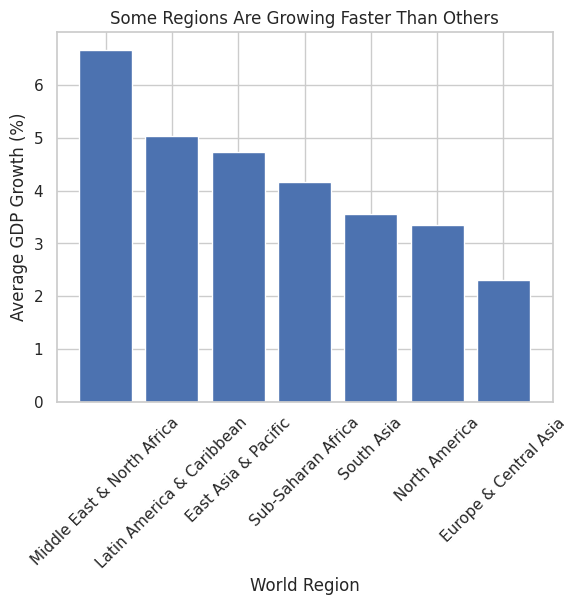

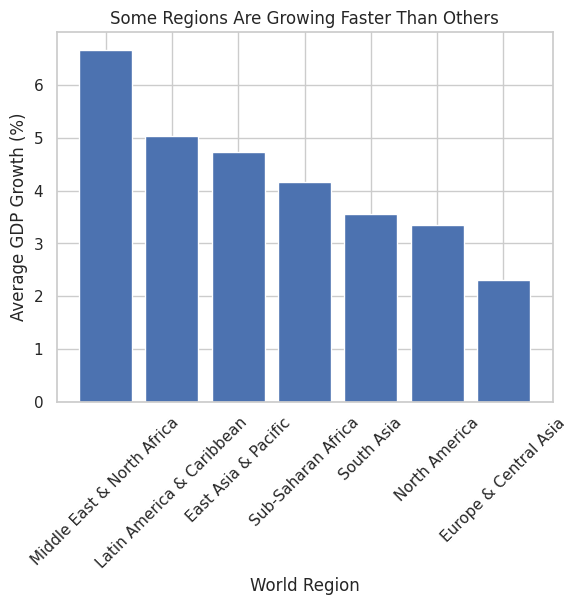

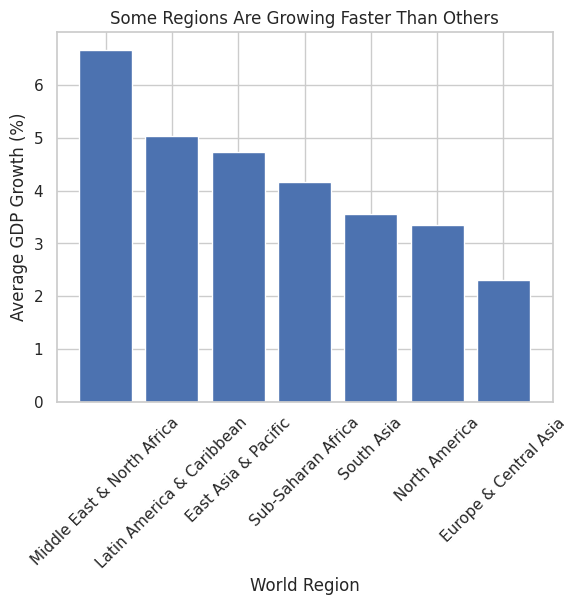

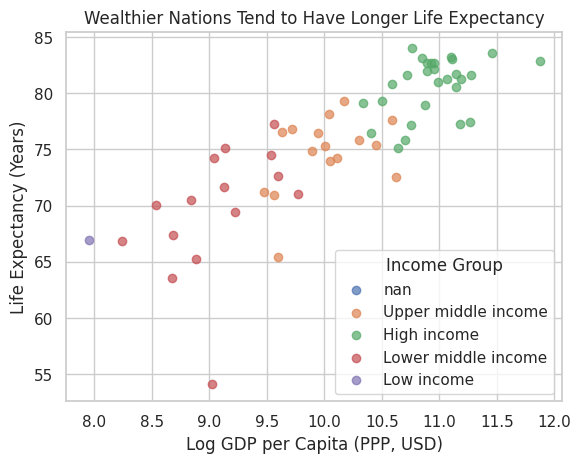

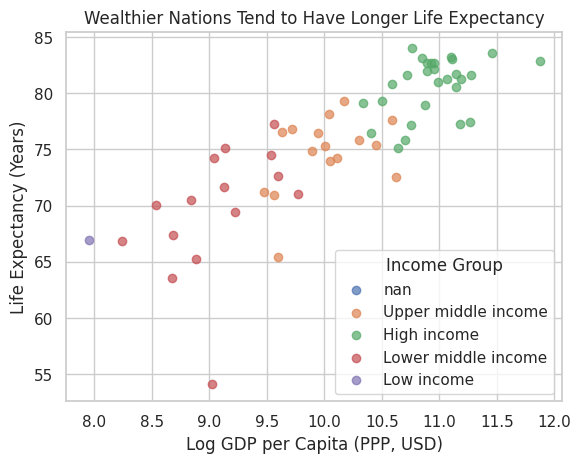

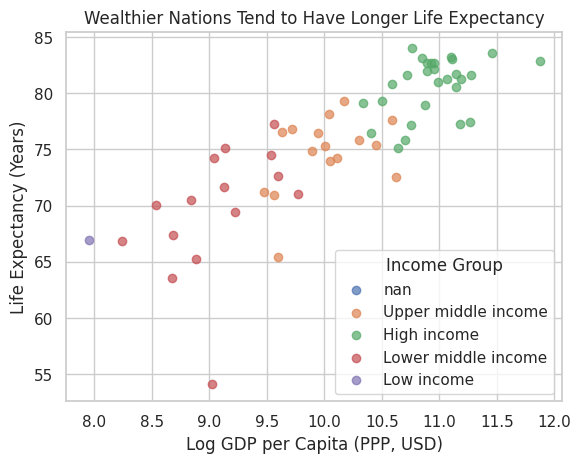

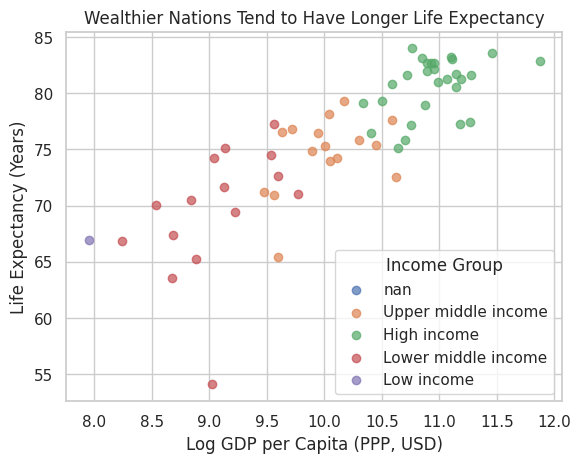

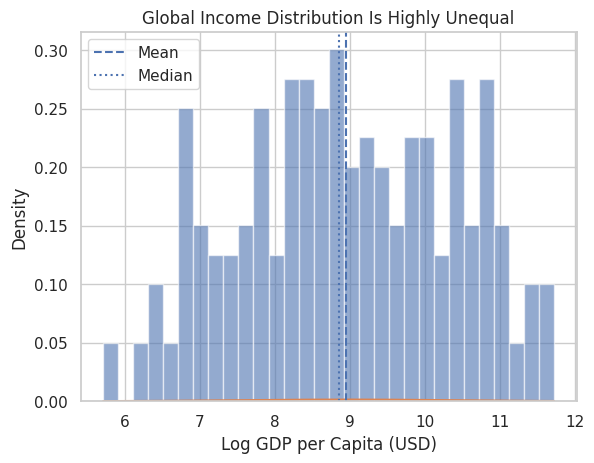

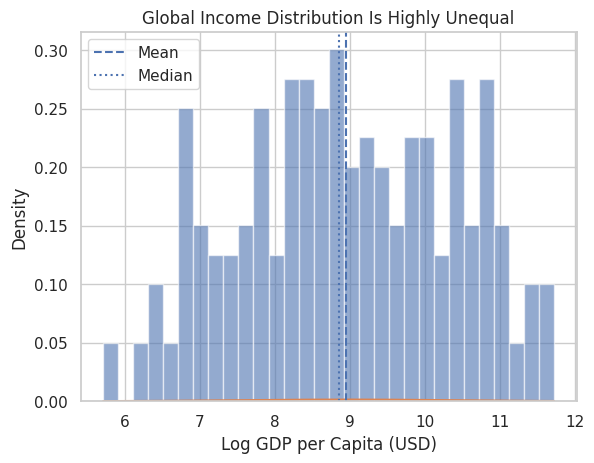

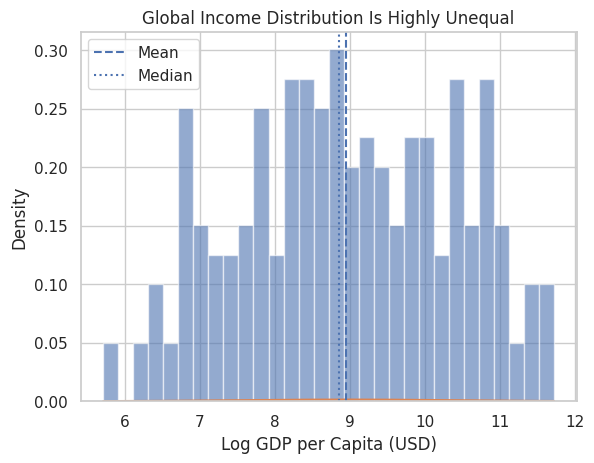

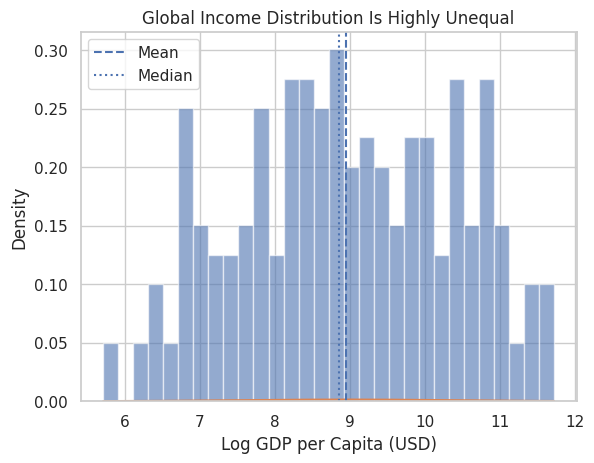

In [ ]:
check_and_submit()


---

# Act I: Comprehend & Predict (25 points)

These questions test whether you can **read code and predict its behavior** without running it. This is a core skill for debugging and code review.

---

## Q1: Code Reading & Prediction (10 points)

Consider this DataFrame:

```python
brics = pd.DataFrame({
    'country': ['USA', 'China', 'India', 'Brazil', 'Germany'],
    'gdp_growth': [2.5, 5.2, 6.8, 1.1, 0.3],
    'population_millions': [335, 1412, 1408, 214, 84],
    'continent': ['Americas', 'Asia', 'Asia', 'Americas', 'Europe']
})
```

**Predict the output of each expression WITHOUT running code.** Trace through the operations by hand.

---

**Q1a (3 pts):** What does this return?
```python
brics[brics['gdp_growth'] > 3].sort_values('gdp_growth', ascending=False)['country'].tolist()
```

**Q1b (3 pts):** Which continent has the highest mean GDP growth?
```python
brics.groupby('continent')['gdp_growth'].mean().idxmax()
```

**Q1c (4 pts):** What does this function return for the given input?
```python
def classify_economy(row):
    if row['gdp_growth'] > 5:
        return 'Fast'
    elif row['gdp_growth'] > 2:
        return 'Moderate'
    else:
        return 'Slow'

classify_economy({'gdp_growth': 2.0})
```
*Hint: Pay attention to `>` vs `>=`.*

In [ ]:
# Your predictions (fill in the blanks)
q1_filter = ['India', 'China']  # Q1a: a list of country names
q1_group = 'Asia'   # Q1b: a string (continent name)
q1_func = 'Slow'    # Q1c: a string ('Fast', 'Moderate', or 'Slow')

In [ ]:
grader.check("q1")

q1 results: All test cases passed!

---

## Q2: Bug Diagnosis & Fix (8 points)

Two buggy pandas code blocks are shown below. For each, **write a corrected function** that produces the right result.

---

### Bug A (4 pts): Boolean Filter

This code is supposed to filter countries with GDP growth above 3 AND population above 100 million:

```python
# BUGGY:
result = df[df['gdp_growth'] > 3 & df['population_millions'] > 100]
```

Write `fix_filter(df)` that returns the correctly filtered DataFrame.

### Bug B (4 pts): Regional Average

This code claims to compute “average GDP by region” but uses the wrong aggregation:

```python
# BUGGY: "average GDP by region" but uses .sum()
regional_avg = df.groupby('region')['gdp_billions'].sum()
```

Write `fix_regional_gdp(df)` that returns a Series of **mean** GDP by region.

In [ ]:
def fix_filter(df):
    return df[(df['gdp_growth'] > 3) & (df['population_millions'] > 100)]

def fix_regional_gdp(df):
    return df.groupby('region')['gdp_billions'].mean()

In [ ]:
grader.check("q2")

q2 results: All test cases passed!

---

## Q3: Code Evaluation (7 points)

Two implementations of “find top 5 countries by GDP per capita”:

**Implementation A** (for loop):
```python
def top5_loop(df):
    sorted_data = []
    for i, row in df.iterrows():
        inserted = False
        for j in range(len(sorted_data)):
            if row['gdp_per_capita'] > sorted_data[j][1]:
                sorted_data.insert(j, (row['country'], row['gdp_per_capita']))
                inserted = True
                break
        if not inserted:
            sorted_data.append((row['country'], row['gdp_per_capita']))
    return sorted_data[:5]
```

**Implementation B** (pandas):
```python
def top5_pandas(df):
    return df.nlargest(5, 'gdp_per_capita')[['country', 'gdp_per_capita']]
```

Answer the questions below.

In [ ]:
# Which implementation is better? ("A" or "B")
q3_better ='B'

# Why? Write a sentence (> 30 characters) explaining your reasoning.
q3_why = q3_why = "Implementation B is better because it uses built-in pandas functions that process the whole column efficientely instead of checking each row one by one in a python loop"

# Estimate: How many times faster is the better implementation
# on a DataFrame with 10,000 rows? (Give a number between 50 and 5000)
q3_estimate = 600

In [ ]:
grader.check("q3")

q3 results: All test cases passed!

---

## Reflection: Comprehend

You just traced code by hand, diagnosed bugs, and evaluated two implementations. Take 2 minutes to reflect while it's fresh.

**Hardest moment:** Which question made you pause longest, and what did you try first? (1-2 sentences)

_Your answer here_

**AI interaction:** If you used AI, paste your single best prompt and note what it got right or wrong. If you didn't, what resource helped most? (2-3 sentences)
"My code is showing Name Error for q3_better, q3_why and q3_estimate even though my answers are correct. What does this mean and how do I fix it?"

**Surprise:** What behaved differently than you expected? (1 sentence)

The prompt didn't help but then I went through the code again and I had added an extra space and then the code worked.

---

# Act II: Analyze & Build (45 points)

Now you’ll work with the full `world` DataFrame to build analysis tools for your data brief.

---

## Q4: Analysis Functions (15 points)

Write two reusable analysis functions. Both operate on the `world` DataFrame.

In [ ]:
def top_n_by_indicator(df, indicator, n):
    """Return top N countries by any indicator.

    Args:
        df: DataFrame with 'country' column and indicator columns
        indicator: Column name to rank by (e.g., 'gdp_growth')
        n: Number of countries to return

    Returns:
        DataFrame with columns ['country', indicator], sorted descending
    """
    return df.nlargest(n, indicator)[['country', indicator]]


def compare_regions(df, indicator):
    """Compare regions by mean value of any indicator.

    Args:
        df: DataFrame with 'region' column and indicator columns
        indicator: Column name to compare

    Returns:
        Series of mean values by region, sorted descending
    """
    return df.groupby('region')[indicator].mean().sort_values(ascending=False)

In [ ]:
# Test your functions
print("Top 5 by GDP growth:")
print(top_n_by_indicator(world, 'gdp_growth', 5))
print("\nRegional comparison (GDP growth):")
print(compare_regions(world, 'gdp_growth'))

Top 5 by GDP growth:
          country  gdp_growth
65659      Guyana   63.334634
65756   St. Lucia   20.388443
65643        Fiji   17.745127
65596    Barbados   17.226463
65611  Cabo Verde   15.843676

Regional comparison (GDP growth):
region
Middle East & North Africa    6.666097
Latin America & Caribbean     5.033805
East Asia & Pacific           4.735740
Sub-Saharan Africa            4.154927
South Asia                    3.553884
North America                 3.350706
Europe & Central Asia         2.297814
Name: gdp_growth, dtype: float64


In [ ]:
grader.check("q4")

q4 results: All test cases passed!

---

## Q5: Visualizations (15 points)

Create three visualization functions. Each must return a `matplotlib.figure.Figure` object.

**Tips:**
- Title should describe the *insight*, not just the variables (e.g., “Wealthier Nations Live Longer” not “GDP vs Life Expectancy”)
- Axis labels should include units
- Use color for meaning, not decoration

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regional_growth(df):
    """Bar chart: mean GDP growth by region. Returns Figure."""

    regional_mean = (
        df.groupby("region")["gdp_growth"]
        .mean()
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots()

    ax.bar(regional_mean.index, regional_mean.values)

    ax.set_title("Some Regions Are Growing Faster Than Others")
    ax.set_xlabel("World Region")
    ax.set_ylabel("Average GDP Growth (%)")

    ax.tick_params(axis='x', rotation=45)

    return fig


def plot_wealth_health(df):
    """Scatter: log(GDP per capita PPP) vs life expectancy colored by income group."""

    fig, ax = plt.subplots()

    for group in df["income_group"].unique():
        subset = df[df["income_group"] == group]

        ax.scatter(
            np.log(subset["gdp_per_capita_ppp"]),
            subset["life_expectancy"],
            alpha=0.7,
            label=group
        )

    ax.set_title("Wealthier Nations Tend to Have Longer Life Expectancy")
    ax.set_xlabel("Log GDP per Capita (PPP, USD)")
    ax.set_ylabel("Life Expectancy (Years)")
    ax.legend(title="Income Group")

    return fig


def plot_gdp_distribution(df):
    """Histogram: GDP per capita distribution with KDE approximation."""

    data = df["gdp_per_capita"].dropna()
    log_data = np.log(data)

    fig, ax = plt.subplots()

    ax.hist(log_data, bins=30, density=True, alpha=0.6)

    # KDE using numpy
    density = np.exp(-(log_data - log_data.mean())**2 /
                     (2 * log_data.std()**2))
    density = density / (density.sum() * (log_data.max() - log_data.min()))

    xs = np.linspace(log_data.min(), log_data.max(), 200)
    kde = np.exp(-(xs - log_data.mean())**2 /
                 (2 * log_data.std()**2))
    kde = kde / (kde.sum() * (xs.max() - xs.min()))

    ax.plot(xs, kde)

    mean_val = log_data.mean()
    median_val = log_data.median()

    ax.axvline(mean_val, linestyle="--", label="Mean")
    ax.axvline(median_val, linestyle=":", label="Median")

    ax.set_title("Global Income Distribution Is Highly Unequal")
    ax.set_xlabel("Log GDP per Capita (USD)")
    ax.set_ylabel("Density")
    ax.legend()

    return fig

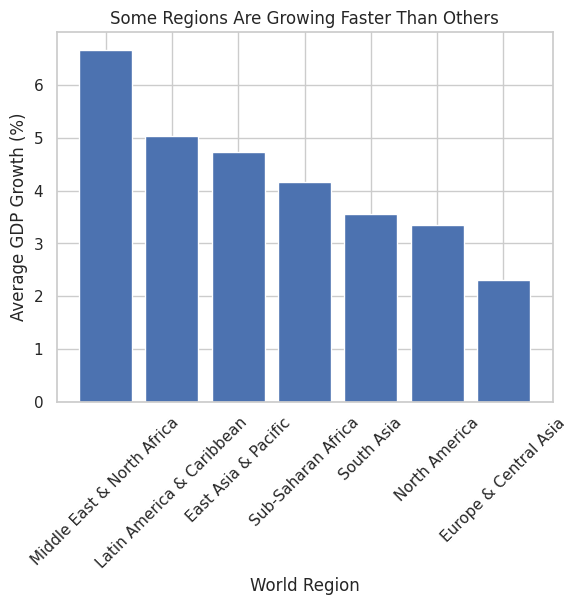

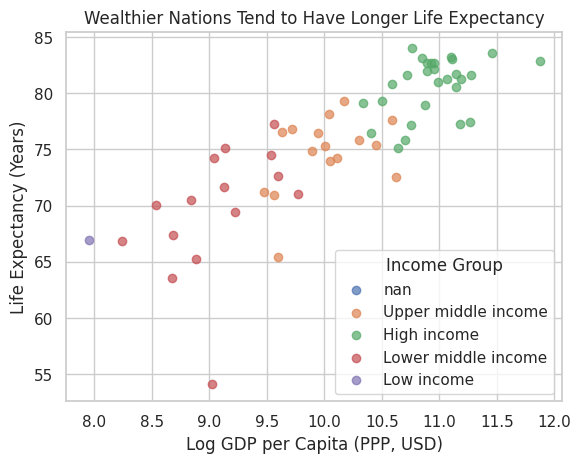

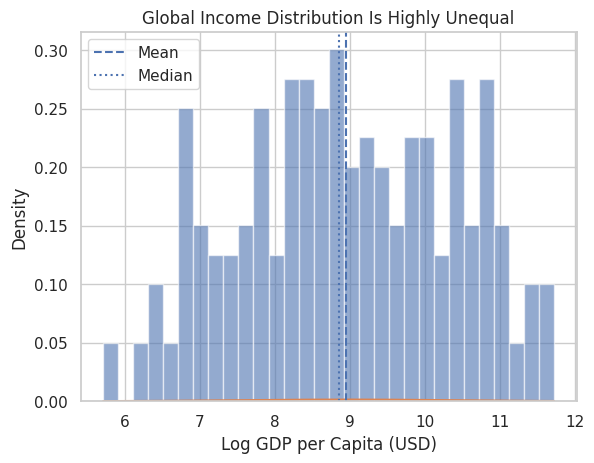

In [ ]:
# Display your plots
fig1 = plot_regional_growth(world)
plt.show()
fig2 = plot_wealth_health(world)
plt.show()
fig3 = plot_gdp_distribution(world)
plt.show()

q5 results: All test cases passed!

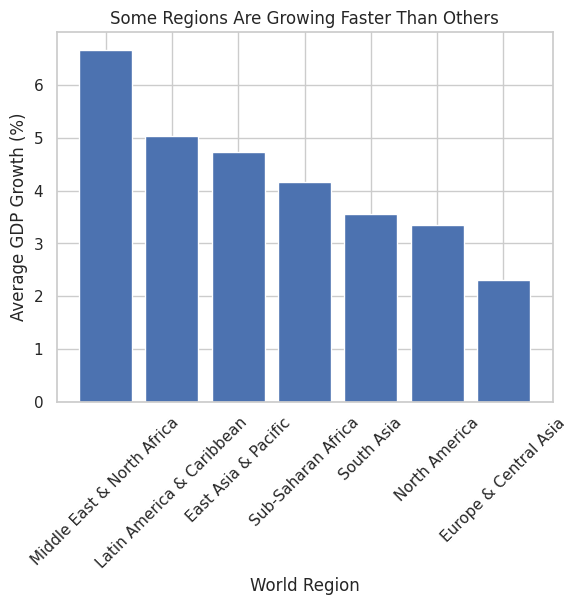

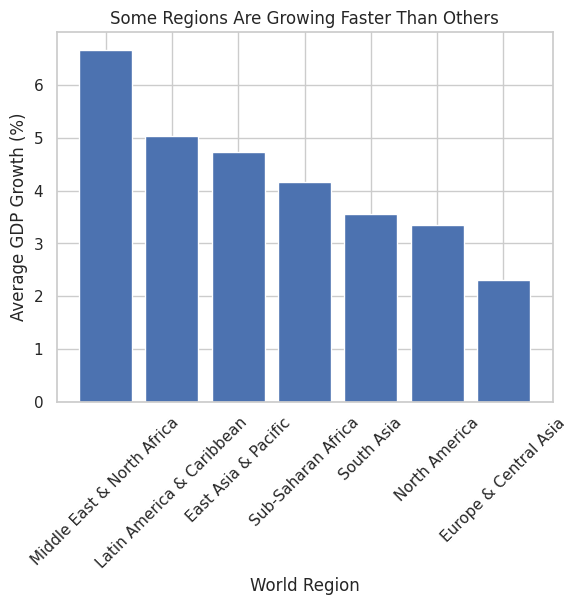

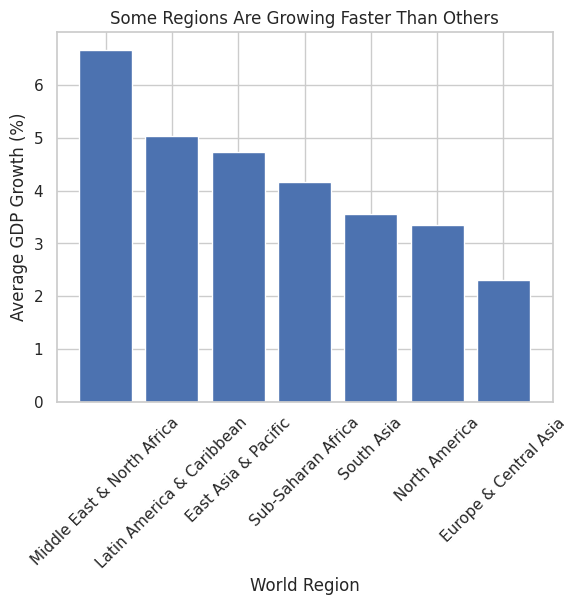

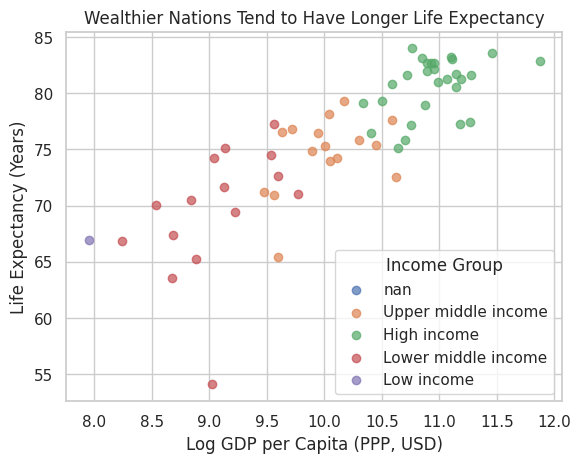

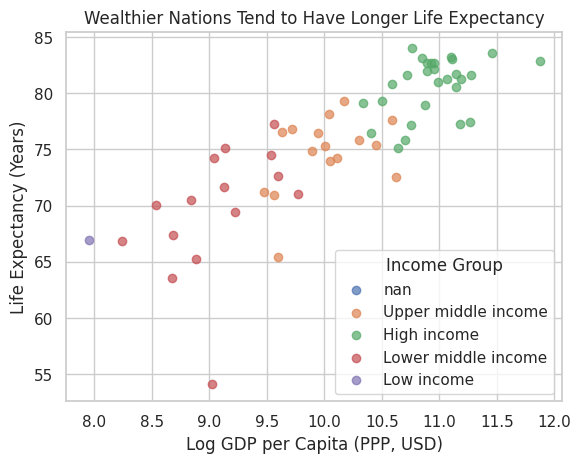

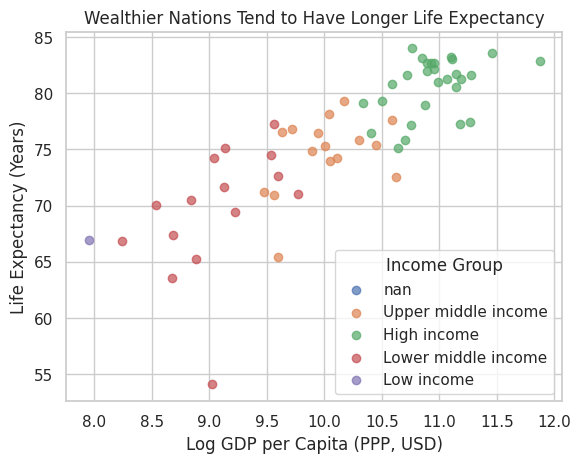

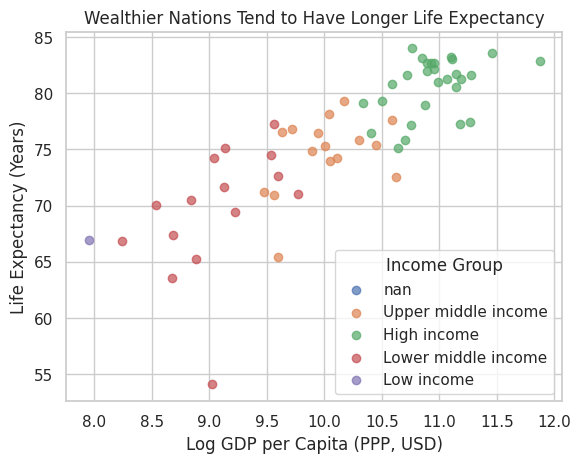

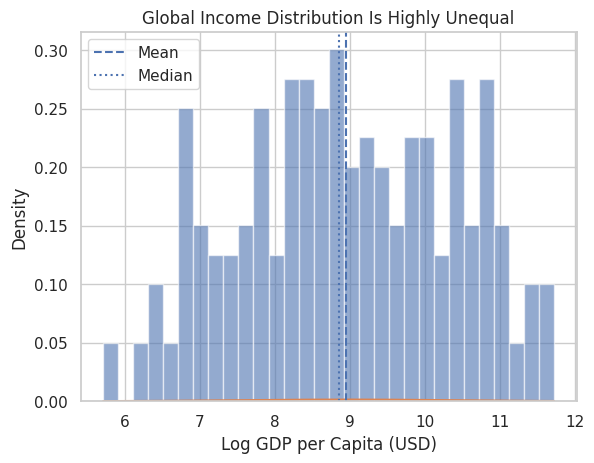

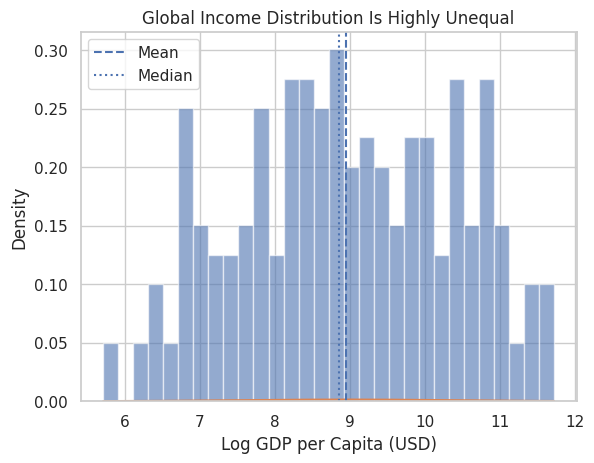

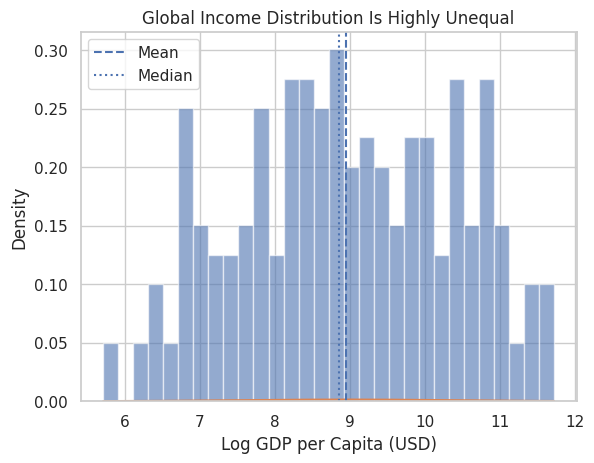

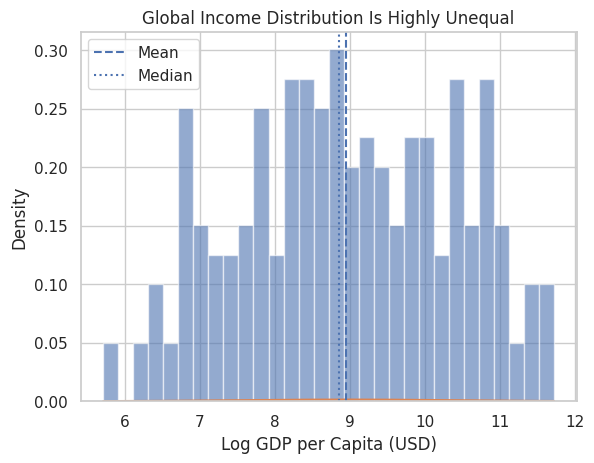

In [ ]:
grader.check("q5")

---

## Q6: Confident Challenge — Economic Brief (15 points)

No scaffolding. Write a function that builds a comprehensive economic data brief from the `world` DataFrame.

**Specification:**

```python
brief = create_economic_brief(world)
# brief == {
#     'top_5_gdp': ['United States', 'China', ...],      # by total GDP (gdp_billions), descending
#     'fastest_5': ['Saudi Arabia', 'Malaysia', ...],     # by gdp_growth, descending
#     'regional_ranking': ['South Asia', ...],            # regions sorted by avg gdp_growth, descending
#     'high_vs_low_life_exp': 18.5,                       # mean life_exp of 'High income' minus 'Low income'
# }
```

In [ ]:
def create_economic_brief(df):

    countries = df[df["region"].notna()].copy()

    top_5_gdp = (
        countries.sort_values("gdp_billions", ascending=False)
        .head(5)["country"]
        .tolist()
    )

    fastest_5 = (
        countries.sort_values("gdp_growth", ascending=False)
        .head(5)["country"]
        .tolist()
    )

    regional_ranking = (
        countries.groupby("region")["gdp_growth"]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    means = df.groupby("income_group")["life_expectancy"].mean()

    high_vs_low_life_exp = float(
        means["High income"] - means["Low income"]
    )

    return {
        "top_5_gdp": top_5_gdp,
        "fastest_5": fastest_5,
        "regional_ranking": regional_ranking,
        "high_vs_low_life_exp": high_vs_low_life_exp
    }

In [ ]:
# Test your brief
brief = create_economic_brief(world)
for key, val in brief.items():
    print(f"{key}: {val}")

top_5_gdp: ['United States', 'China', 'Japan', 'Germany', 'India']
fastest_5: ['Saudi Arabia', 'Panama', 'Malaysia', 'Viet Nam', 'India']
regional_ranking: ['Middle East & North Africa', 'Latin America & Caribbean', 'East Asia & Pacific', 'Sub-Saharan Africa', 'South Asia', 'North America', 'Europe & Central Asia']
high_vs_low_life_exp: 13.775123693379783


In [ ]:
grader.check("q6")

q6 results: All test cases passed!

---

## Reflection: Build

You just wrote analysis functions and visualizations from specifications. Reflect before moving on.

**Hardest moment:** Where did you get stuck building your functions or plots? What was your first instinct for fixing it? (1-2 sentences)

The hardest moment was when Q6 kept failing even though the logic seemed correct. I initially assumed the sorting or column name was wrong, but later realized the dataset included aggregate rows like “World” and income groups that needed to be filtered out as was the case with question 9.

**AI interaction:** If you used AI, paste your best prompt and note what it got right or wrong. If you didn't, what strategy helped most? (2-3 sentences)

"My plotting function passes most tests, but one test checks len(_fig3.axes[0].lines) >= 3 and fails even though I added mean and median vertical lines. What could be causing that?"

**Surprise:** Did any function, test, or plot behave differently than you expected? (1 sentence)

_Your answer here_

---

# Act III: Evaluate & Extend (30 points)

Your supervisor asked an AI to help with some analysis. You need to review its work.

---

## Q7: AI Code Review (12 points)

Your colleague used an AI to generate two code blocks. Each has a subtle problem. **Identify the flaw and write a corrected version.**

---

### AI Code Block 1 (6 pts)

The AI was asked to add a GDP per capita column:

```python
# "AI-generated" — uses a for loop to add GDP per capita
def ai_gdp_per_capita(df):
    result = df.copy()
    for i in range(len(df)):
        result.loc[i, 'gdp_per_capita'] = (
            df.loc[i, 'gdp_current_usd'] / df.loc[i, 'population']
        )
    return result
```

**Problems:** Loop-based (slow), assumes 0-based integer index (breaks if index is non-default).

Write `add_gdp_per_capita(df)` — a vectorized version that works regardless of index.

---

### AI Code Block 2 (6 pts)

The AI was asked to find “the region with the highest GDP”:

```python
# "AI-generated" — finds "the region with the highest GDP"
def ai_top_region(df):
    return df.groupby('region')['gdp_billions'].mean().idxmax()
```

**Problem:** Uses `.mean()` instead of `.sum()` — computes “region with highest *average* GDP” not “highest *total* GDP.” These give different answers. (Think about it: Europe has many countries with moderate GDP, while Asia has China and India.)

Write `region_total_gdp(df)` returning a Series of **total** GDP by region, sorted descending.

In [ ]:
def add_gdp_per_capita(df):
    """Add a 'gdp_per_capita' column using vectorized division.
    Must work regardless of the DataFrame's index.
    """

    result = df.copy()
    result["gdp_per_capita"] = result["gdp_current_usd"] / result["population"]
    return result


def region_total_gdp(df):
    """Return total (sum) GDP by region, sorted descending."""

    return (
        df.groupby("region")["gdp_billions"]
        .sum()
        .sort_values(ascending=False)
    )

In [ ]:
# Test your corrections
print("GDP per capita (first 3 rows):")
print(add_gdp_per_capita(world)[['country', 'gdp_per_capita']].head(3))
print("\nTotal GDP by region:")
print(region_total_gdp(world))

GDP per capita (first 3 rows):
           country  gdp_per_capita
65580  Afghanistan      357.261153
65581      Albania     7756.961887
65582      Algeria     4960.303343

Total GDP by region:
region
East Asia & Pacific           29913.116365
North America                 27795.259988
Europe & Central Asia         22568.749230
Latin America & Caribbean      5487.346647
South Asia                     4296.455232
Middle East & North Africa     2372.249241
Sub-Saharan Africa             1441.803709
Name: gdp_billions, dtype: float64


In [ ]:
grader.check("q7")

q7 results: All test cases passed!

---

## Q8: Critical Analysis (10 points)

Answer these questions using computation on the `world` DataFrame. Each requires both a calculation and economic interpretation.

In [ ]:
# Q8a (4 pts): Compute the Pearson correlation between log(GDP per capita PPP)
# and life expectancy. This is the strength of the Preston curve.
q8_correlation = np.log(world["gdp_per_capita_ppp"]).corr(world["life_expectancy"])

# Q8b (3 pts): Which income group has the largest absolute difference between
# its actual average life expectancy and the overall average life expectancy?
# (A string like 'High income' or 'Low income')
overall_mean = world["life_expectancy"].mean()
group_means = world.groupby("income_group")["life_expectancy"].mean()

q8_outlier_group = (group_means - overall_mean).abs().idxmax()


# Q8c (3 pts): What GDP growth rate separates the top quartile (75th percentile)?
# Countries above this threshold are the fastest-growing quarter.
q8_threshold = world["gdp_growth"].quantile(0.75)

In [ ]:
print(f"Preston curve correlation: {q8_correlation:.3f}")
print(f"Most deviant income group: {q8_outlier_group}")
print(f"Top quartile GDP growth threshold: {q8_threshold:.1f}%")

Preston curve correlation: 0.809
Most deviant income group: High income
Top quartile GDP growth threshold: 6.4%


In [ ]:
grader.check("q8")

q8 results: All test cases passed!

---

## Q9: Edge Case Handling (8 points)

Your `top_n_by_indicator` function from Q4 works for normal inputs. But real-world data has surprises. Write a **robust version** that handles three edge cases.

In [ ]:
def safe_top_n(df, indicator, n):
    """Robust version of top_n_by_indicator that handles edge cases."""

    # Case 3: indicator column does not exist
    if indicator not in df.columns:
        return df[["country"]].iloc[0:0]

    # Drop rows with NaN values in the indicator column
    clean = df.dropna(subset=[indicator])

    # Case 1: if n is larger than available rows
    n = min(n, len(clean))

    # Sort and return the top rows
    return clean.sort_values(indicator, ascending=False).head(n)[["country", indicator]]

In [ ]:
# Test edge cases
print("Normal case (top 3):")
print(safe_top_n(world, 'gdp_growth', 3))

print("\nn > rows (n=200):")
print(f"Returned {len(safe_top_n(world, 'gdp_growth', 200))} rows (all of them)")

print("\nNonexistent column:")
print(safe_top_n(world, 'nonexistent', 5))

Normal case (top 3):
         country  gdp_growth
65659     Guyana   63.334634
65756  St. Lucia   20.388443
65643       Fiji   17.745127

n > rows (n=200):
Returned 199 rows (all of them)

Nonexistent column:
Empty DataFrame
Columns: [country]
Index: []


In [ ]:
grader.check("q9")

q9 results: All test cases passed!

---

## Reflection: Evaluate

You just reviewed AI-generated code, computed economic statistics, and handled edge cases.

**Hardest moment:** Which question challenged you most? What was your approach before it clicked? (1-2 sentences)

_Your answer here_

**AI interaction:** If you used AI, paste your best prompt and note what it got right or wrong. If you didn't, what helped you crack the hard parts? (2-3 sentences)

_Your answer here_

**Surprise:** What surprised you about how edge cases or AI-generated code behaved? (1 sentence)

_Your answer here_

In [ ]:
used_ai = ___  # True or False

---

# Honor Code

By submitting this assignment, I affirm that:

- [ ] I completed the coding portion following course AI guidelines
- [ ] I completed the inline reflections after each Act honestly
- [ ] I will complete the understanding quiz without external assistance

---

## Final Check

Run `check_and_submit()` one last time before the deadline to make sure your latest scores are saved.


q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!

q8 results: All test cases passed!

q9 results: All test cases passed!

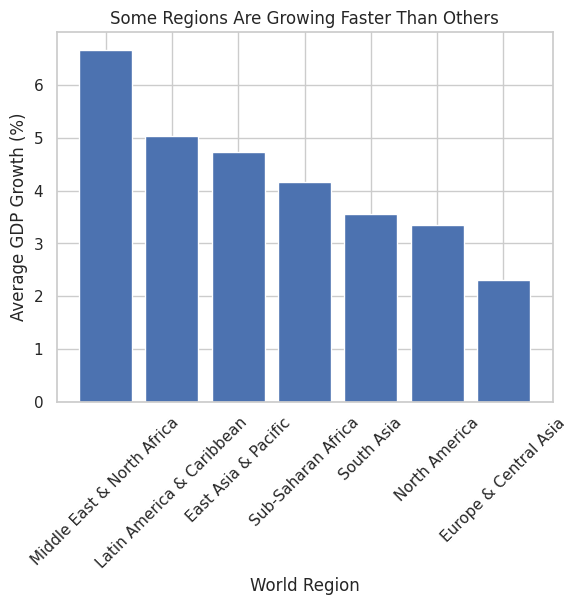

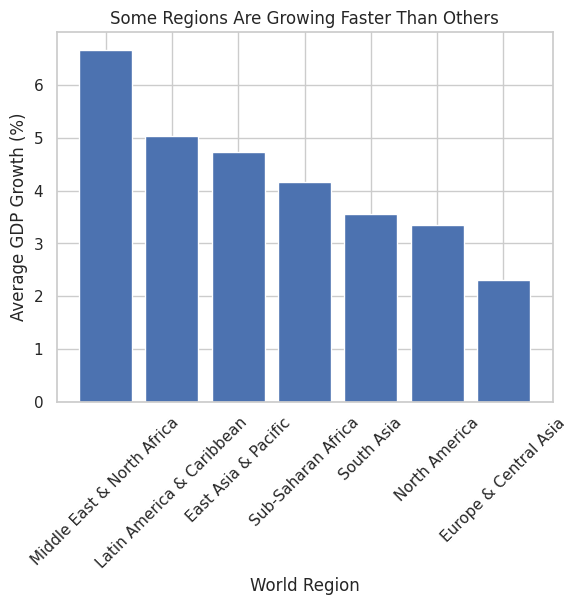

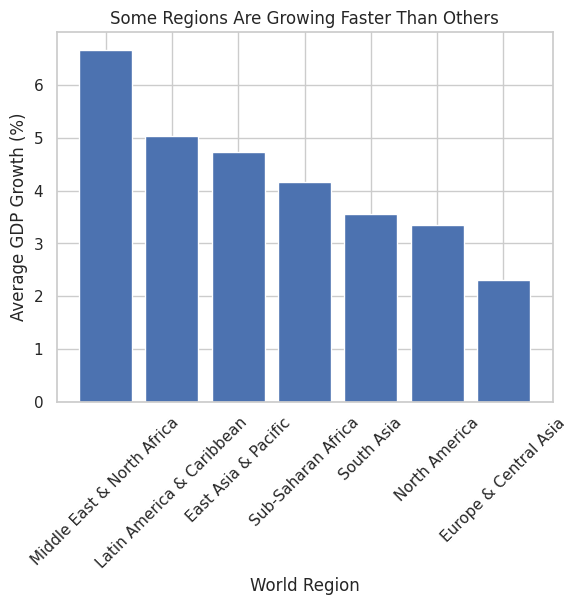

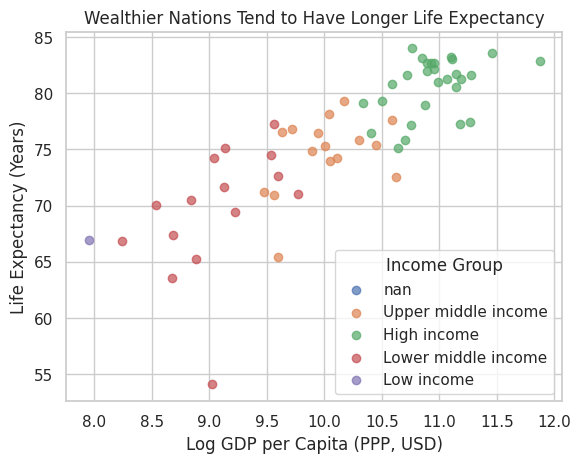

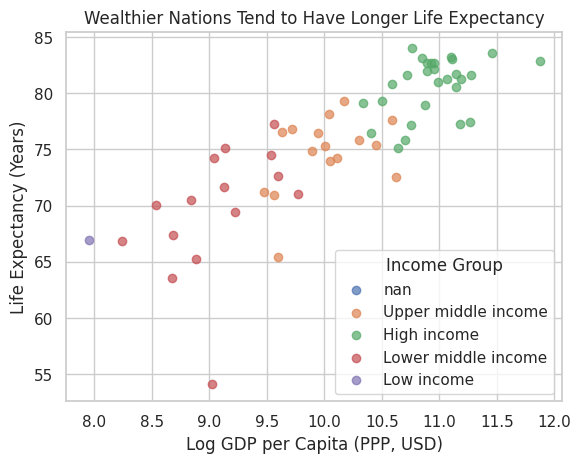

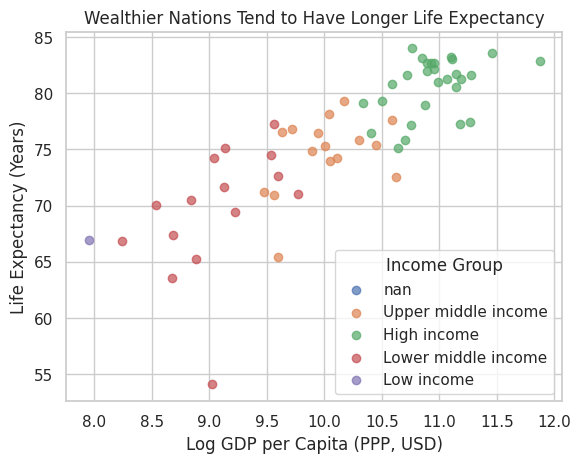

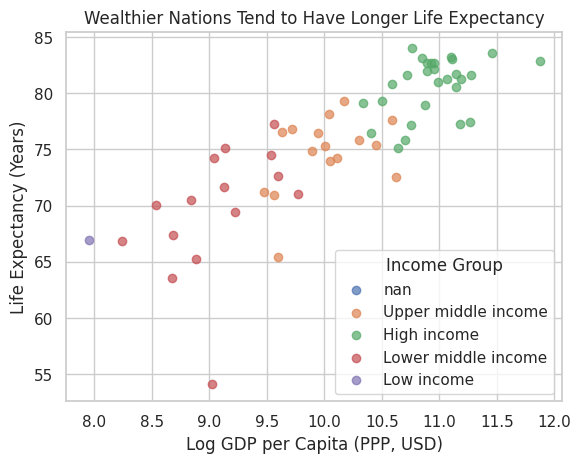

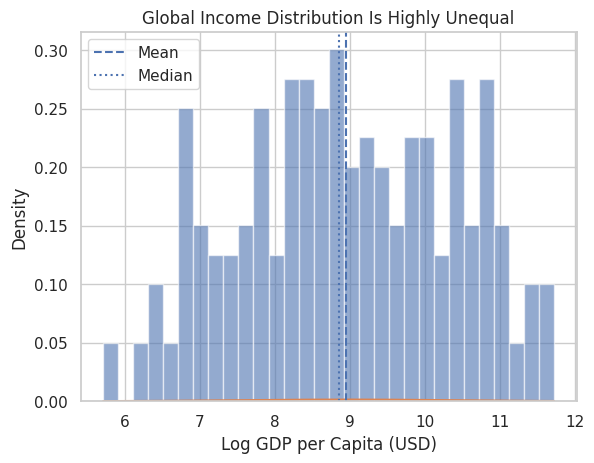

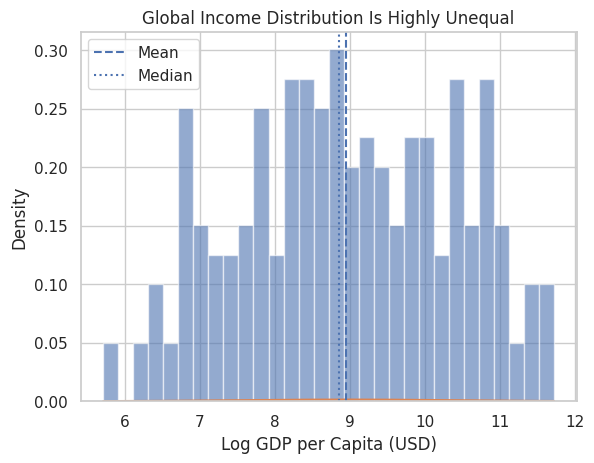

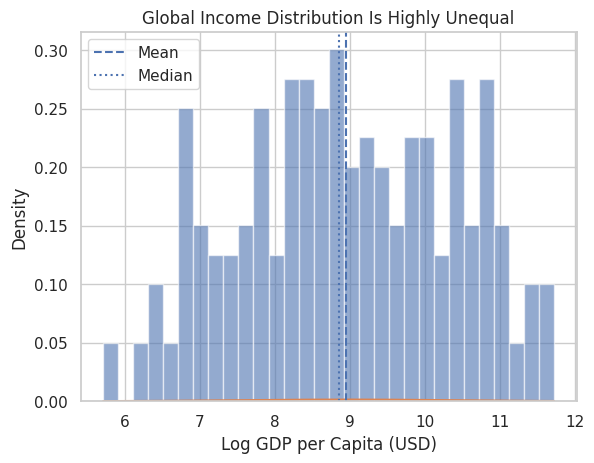

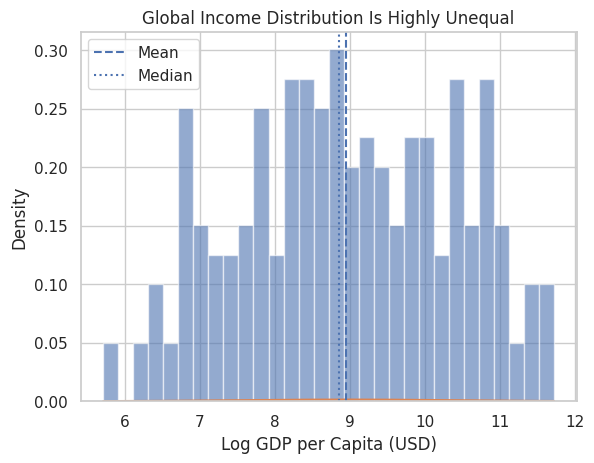

In [ ]:
grader.check_all()

---

**ECO6810: Data Analysis for Economics**

© 2026 Kush Khurana, Ashoka University

Licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/)